In [1]:
# Cell 1 - Imports and setup
# Loading all libraries we need for Day 3 EDA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os
import warnings
warnings.filterwarnings("ignore")

# makes matplotlib charts look cleaner
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 11
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# color palette we'll use throughout
COLORS = px.colors.qualitative.Set2

# paths
BASE_DIR   = os.path.dirname(os.path.abspath(""))
CLEAN_PATH = os.path.join(BASE_DIR, "data", "processed")
CHART_PATH = os.path.join(BASE_DIR, "reports", "charts")
os.makedirs(CHART_PATH, exist_ok=True)

print("All libraries loaded successfully")
print(f"Charts will be saved to: {CHART_PATH}")

All libraries loaded successfully
Charts will be saved to: C:\Users\USER\Desktop\bluestock-fintech-capstone\reports\charts


In [2]:
# Cell 2 - Load all cleaned datasets
# Reading from data/processed/ which we created in Day 2

nav_df   = pd.read_csv(os.path.join(CLEAN_PATH, "clean_nav.csv"),
                        parse_dates=["date"])

fund_df  = pd.read_csv(os.path.join(CLEAN_PATH, "clean_fund_master.csv"),
                        parse_dates=["launch_date"])

aum_df   = pd.read_csv(os.path.join(CLEAN_PATH, "clean_aum_by_fund_house.csv"),
                        parse_dates=["date"])

sip_df   = pd.read_csv(os.path.join(CLEAN_PATH, "clean_monthly_sip_inflows.csv"),
                        parse_dates=["month"])

cat_df   = pd.read_csv(os.path.join(CLEAN_PATH, "clean_category_inflows.csv"),
                        parse_dates=["month"])

folio_df = pd.read_csv(os.path.join(CLEAN_PATH, "clean_industry_folio_count.csv"),
                        parse_dates=["month"])

tx_df    = pd.read_csv(os.path.join(CLEAN_PATH, "clean_transactions.csv"),
                        parse_dates=["transaction_date"])

port_df  = pd.read_csv(os.path.join(CLEAN_PATH, "clean_portfolio_holdings.csv"))

perf_df  = pd.read_csv(os.path.join(CLEAN_PATH, "clean_performance.csv"))

print("All datasets loaded:")
print(f"  nav_df        : {nav_df.shape[0]:,} rows")
print(f"  fund_df       : {fund_df.shape[0]:,} rows")
print(f"  aum_df        : {aum_df.shape[0]:,} rows")
print(f"  sip_df        : {sip_df.shape[0]:,} rows")
print(f"  cat_df        : {cat_df.shape[0]:,} rows")
print(f"  folio_df      : {folio_df.shape[0]:,} rows")
print(f"  tx_df         : {tx_df.shape[0]:,} rows")
print(f"  port_df       : {port_df.shape[0]:,} rows")
print(f"  perf_df       : {perf_df.shape[0]:,} rows")

All datasets loaded:
  nav_df        : 46,000 rows
  fund_df       : 40 rows
  aum_df        : 90 rows
  sip_df        : 48 rows
  cat_df        : 144 rows
  folio_df      : 21 rows
  tx_df         : 32,778 rows
  port_df       : 322 rows
  perf_df       : 40 rows


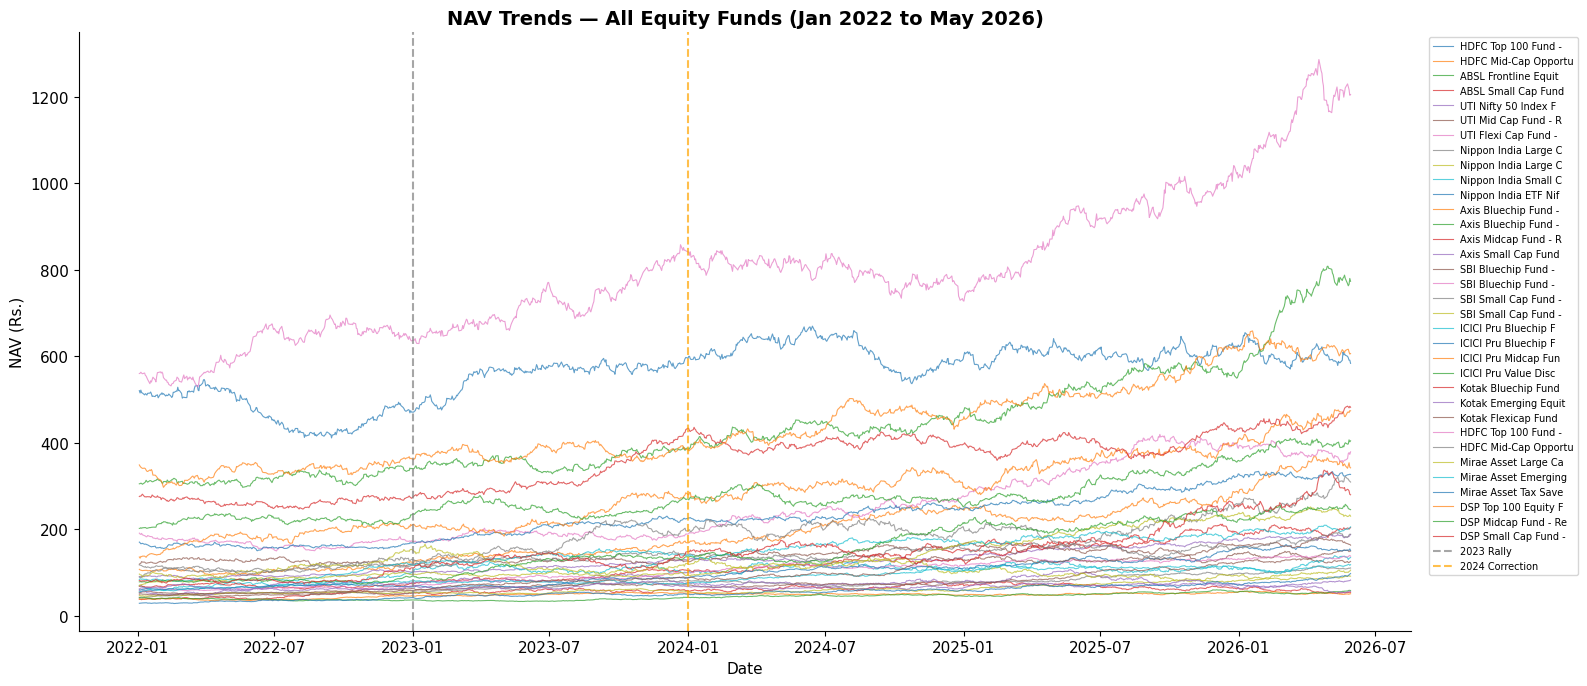

Chart saved: nav_trends_equity.png


In [3]:
# Cell 3 - Task 1: NAV trend analysis
# using matplotlib instead of plotly to avoid memory issues

nav_merged = nav_df.merge(
    fund_df[["amfi_code", "scheme_name", "category"]],
    on="amfi_code", how="left"
)

equity_nav = nav_merged[nav_merged["category"] == "Equity"]

fig, ax = plt.subplots(figsize=(16, 7))

# plot each fund as a separate line
for code in equity_nav["amfi_code"].unique():
    fund_data = equity_nav[equity_nav["amfi_code"] == code]
    name = fund_data["scheme_name"].iloc[0][:20]
    ax.plot(fund_data["date"], fund_data["nav"],
            linewidth=0.8, alpha=0.7, label=name)

# mark key market events
ax.axvline(pd.Timestamp("2023-01-01"), color="gray",
           linestyle="--", alpha=0.7, label="2023 Rally")
ax.axvline(pd.Timestamp("2024-01-01"), color="orange",
           linestyle="--", alpha=0.7, label="2024 Correction")

ax.set_title("NAV Trends — All Equity Funds (Jan 2022 to May 2026)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("NAV (Rs.)")
ax.legend(bbox_to_anchor=(1.01, 1), fontsize=7, ncol=1)

plt.tight_layout()
plt.savefig(os.path.join(CHART_PATH, "nav_trends_equity.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: nav_trends_equity.png")

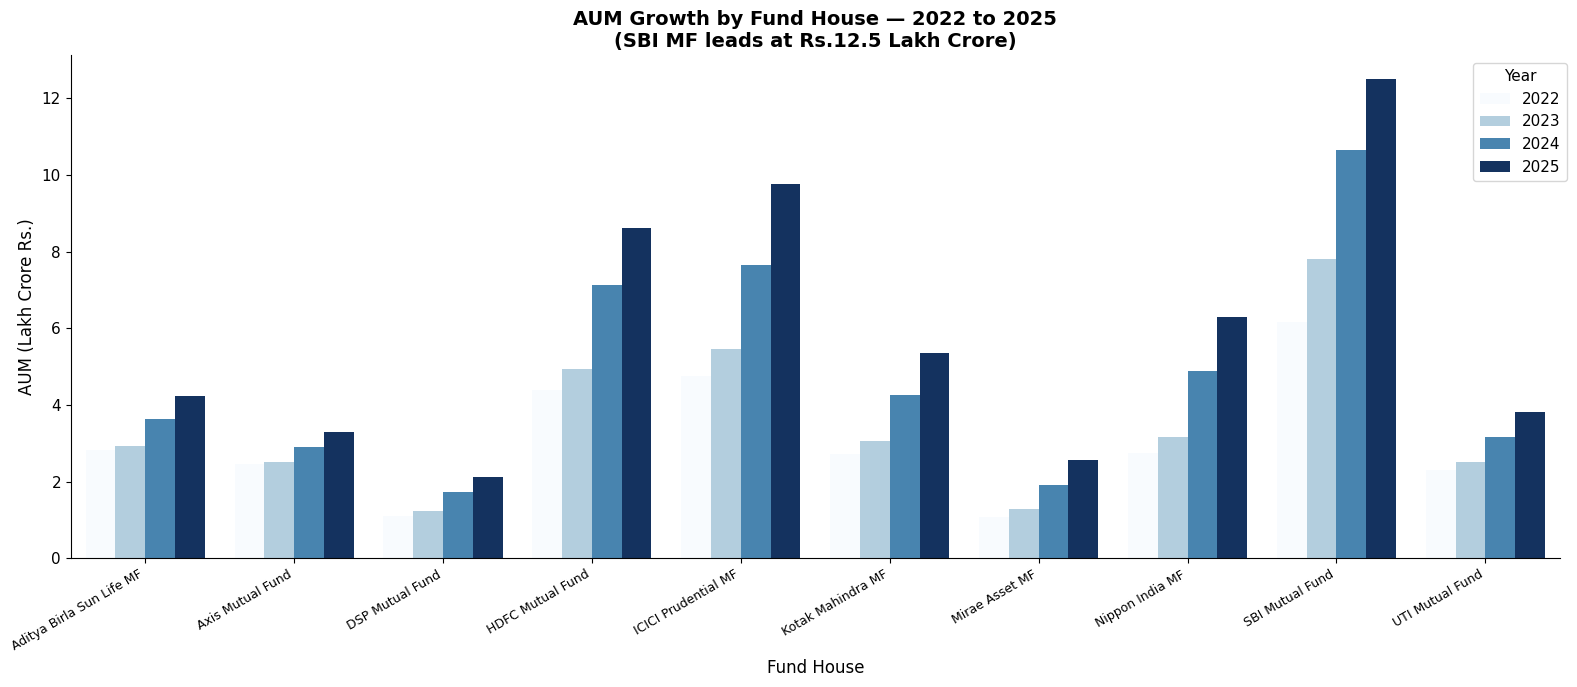

Chart saved: aum_growth_by_fund_house.png


In [4]:
# Cell 4 - Task 2: AUM growth by fund house 2022-2025

aum_df["year"] = aum_df["date"].dt.year
aum_yearly = aum_df.groupby(["fund_house", "year"])["aum_lakh_crore"].mean().reset_index()

fig, ax = plt.subplots(figsize=(16, 7))

sns.barplot(
    data=aum_yearly,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year",
    palette="Blues",
    ax=ax
)

ax.set_title("AUM Growth by Fund House — 2022 to 2025\n(SBI MF leads at Rs.12.5 Lakh Crore)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Fund House", fontsize=12)
ax.set_ylabel("AUM (Lakh Crore Rs.)", fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)
ax.legend(title="Year", bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.savefig(os.path.join(CHART_PATH, "aum_growth_by_fund_house.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: aum_growth_by_fund_house.png")

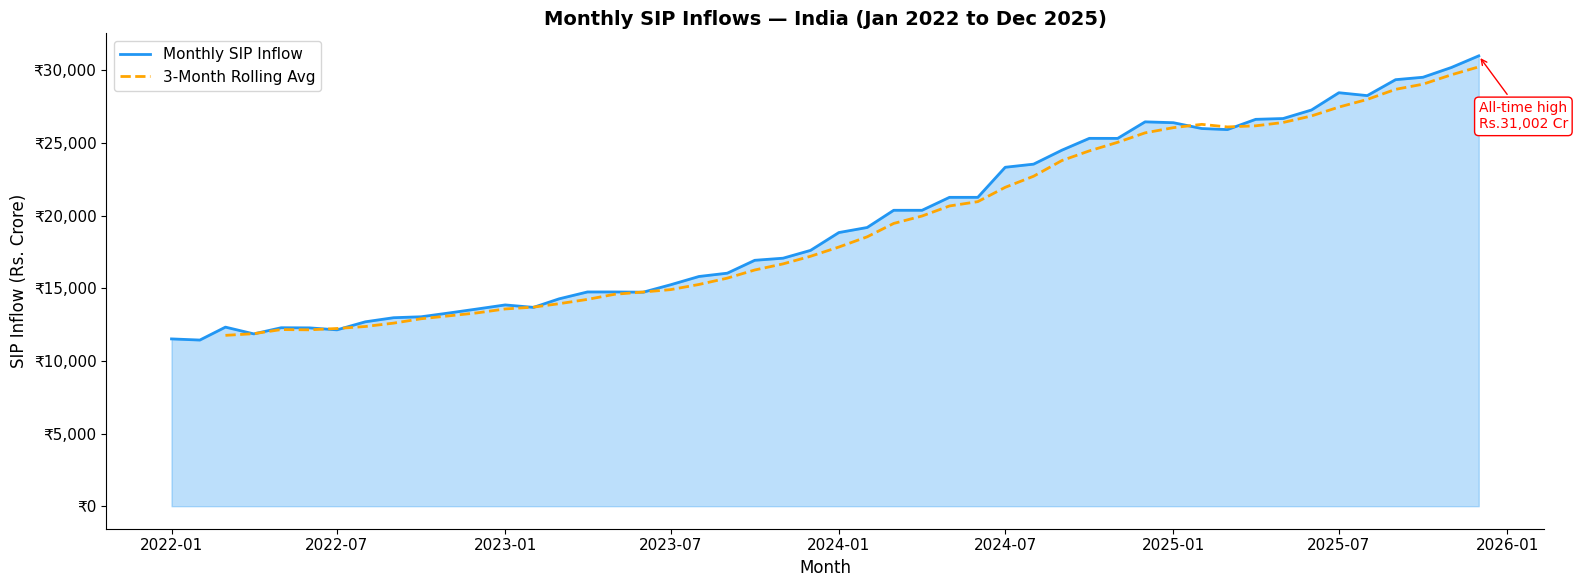

Chart saved: sip_inflow_trend.png


In [5]:
# Cell 5 - Task 3: Monthly SIP inflow trend

sip_df["rolling_avg"] = sip_df["sip_inflow_crore"].rolling(3).mean()

fig, ax = plt.subplots(figsize=(16, 6))

ax.fill_between(sip_df["month"], sip_df["sip_inflow_crore"],
                alpha=0.3, color="#2196F3")
ax.plot(sip_df["month"], sip_df["sip_inflow_crore"],
        color="#2196F3", linewidth=2, label="Monthly SIP Inflow")
ax.plot(sip_df["month"], sip_df["rolling_avg"],
        color="orange", linewidth=2, linestyle="--", label="3-Month Rolling Avg")

# mark the all time high
max_idx = sip_df["sip_inflow_crore"].idxmax()
max_val = sip_df.loc[max_idx, "sip_inflow_crore"]
max_date = sip_df.loc[max_idx, "month"]
ax.annotate(f"All-time high\nRs.{max_val:,} Cr",
            xy=(max_date, max_val),
            xytext=(max_date, max_val - 5000),
            arrowprops=dict(arrowstyle="->", color="red"),
            fontsize=10, color="red",
            bbox=dict(boxstyle="round", facecolor="white", edgecolor="red"))

ax.set_title("Monthly SIP Inflows — India (Jan 2022 to Dec 2025)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("SIP Inflow (Rs. Crore)", fontsize=12)
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f"₹{x:,.0f}")
)

plt.tight_layout()
plt.savefig(os.path.join(CHART_PATH, "sip_inflow_trend.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: sip_inflow_trend.png")

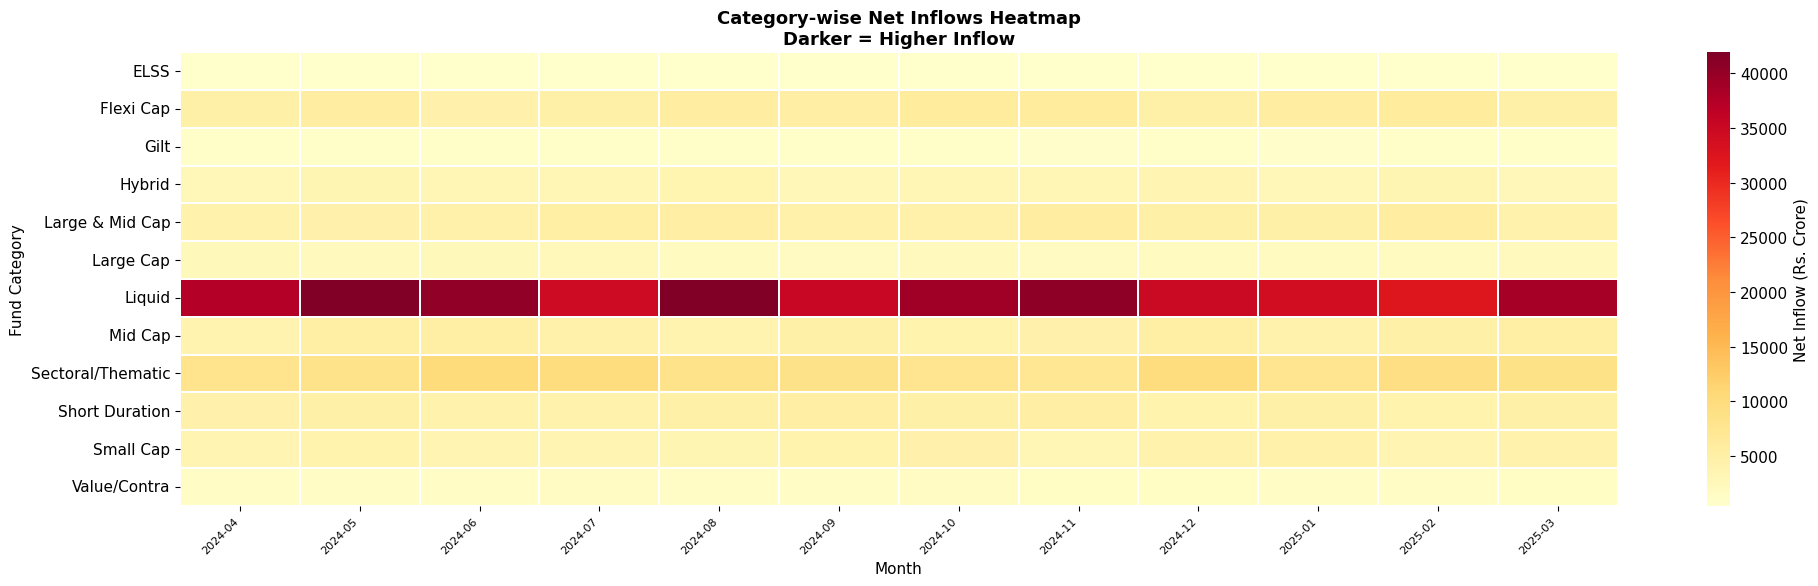

Chart saved: category_inflow_heatmap.png


In [6]:
# Cell 6 - Task 4: Category wise inflow heatmap

cat_df["month_str"] = cat_df["month"].dt.strftime("%Y-%m")
pivot = cat_df.pivot_table(
    index="category",
    columns="month_str",
    values="net_inflow_crore",
    aggfunc="sum"
)

fig, ax = plt.subplots(figsize=(20, 6))

sns.heatmap(
    pivot,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.3,
    ax=ax,
    cbar_kws={"label": "Net Inflow (Rs. Crore)"}
)

ax.set_title("Category-wise Net Inflows Heatmap\nDarker = Higher Inflow",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("Fund Category", fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(CHART_PATH, "category_inflow_heatmap.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: category_inflow_heatmap.png")

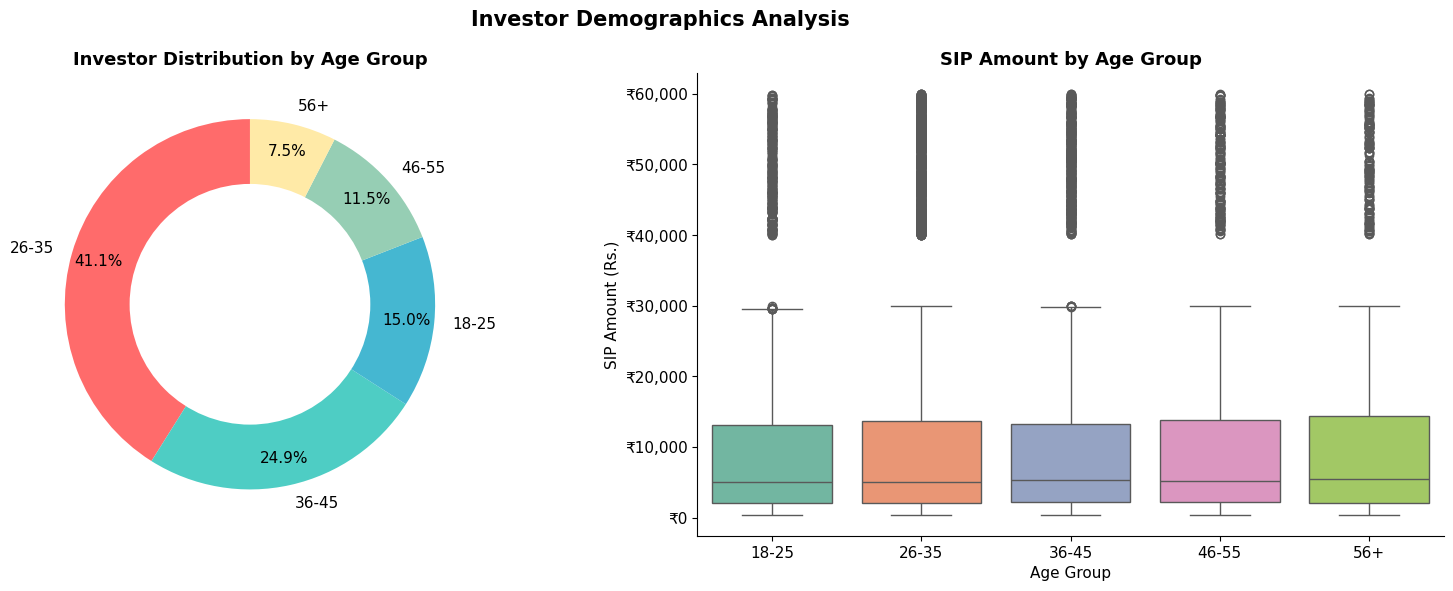

Chart saved: investor_demographics.png


In [7]:
# Cell 7 - Task 5: Investor demographics

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# pie chart - age group distribution
age_counts = tx_df["age_group"].value_counts()
colors_pie = ["#FF6B6B", "#4ECDC4", "#45B7D1", "#96CEB4", "#FFEAA7"]

axes[0].pie(
    age_counts.values,
    labels=age_counts.index,
    autopct="%1.1f%%",
    colors=colors_pie,
    startangle=90,
    pctdistance=0.85
)
centre = plt.Circle((0, 0), 0.65, fc="white")
axes[0].add_patch(centre)
axes[0].set_title("Investor Distribution by Age Group",
                   fontsize=13, fontweight="bold")

# box plot - SIP amount by age group
sip_only = tx_df[tx_df["transaction_type"] == "SIP"]
sns.boxplot(
    data=sip_only,
    x="age_group",
    y="amount_inr",
    palette="Set2",
    order=["18-25", "26-35", "36-45", "46-55", "56+"],
    ax=axes[1]
)
axes[1].set_title("SIP Amount by Age Group", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Age Group", fontsize=11)
axes[1].set_ylabel("SIP Amount (Rs.)", fontsize=11)
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f"₹{x:,.0f}")
)

plt.suptitle("Investor Demographics Analysis", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(CHART_PATH, "investor_demographics.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: investor_demographics.png")

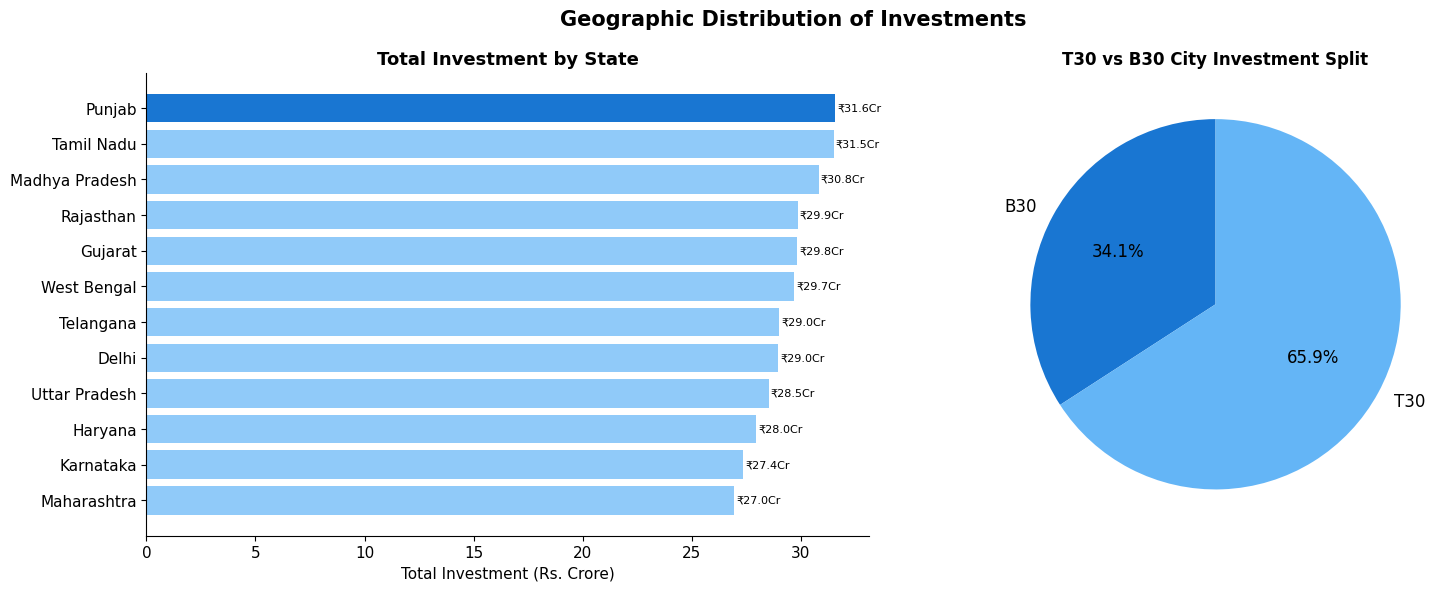

Chart saved: geographic_distribution.png


In [8]:
# Cell 8 - Task 6: Geographic distribution

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# horizontal bar - investment by state
state_inv = tx_df.groupby("state")["amount_inr"].sum().sort_values()
state_cr  = state_inv / 1e7

colors_bar = ["#1976D2" if v == state_cr.max() else "#90CAF9"
              for v in state_cr.values]

axes[0].barh(state_cr.index, state_cr.values, color=colors_bar)
axes[0].set_title("Total Investment by State", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Total Investment (Rs. Crore)", fontsize=11)

for i, v in enumerate(state_cr.values):
    axes[0].text(v + 0.1, i, f"₹{v:.1f}Cr", va="center", fontsize=8)

# pie - T30 vs B30
tier = tx_df.groupby("city_tier")["amount_inr"].sum()
axes[1].pie(
    tier.values,
    labels=tier.index,
    autopct="%1.1f%%",
    colors=["#1976D2", "#64B5F6"],
    startangle=90,
    textprops={"fontsize": 12}
)
axes[1].set_title("T30 vs B30 City Investment Split",
                   fontsize=12, fontweight="bold")

plt.suptitle("Geographic Distribution of Investments",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(CHART_PATH, "geographic_distribution.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: geographic_distribution.png")

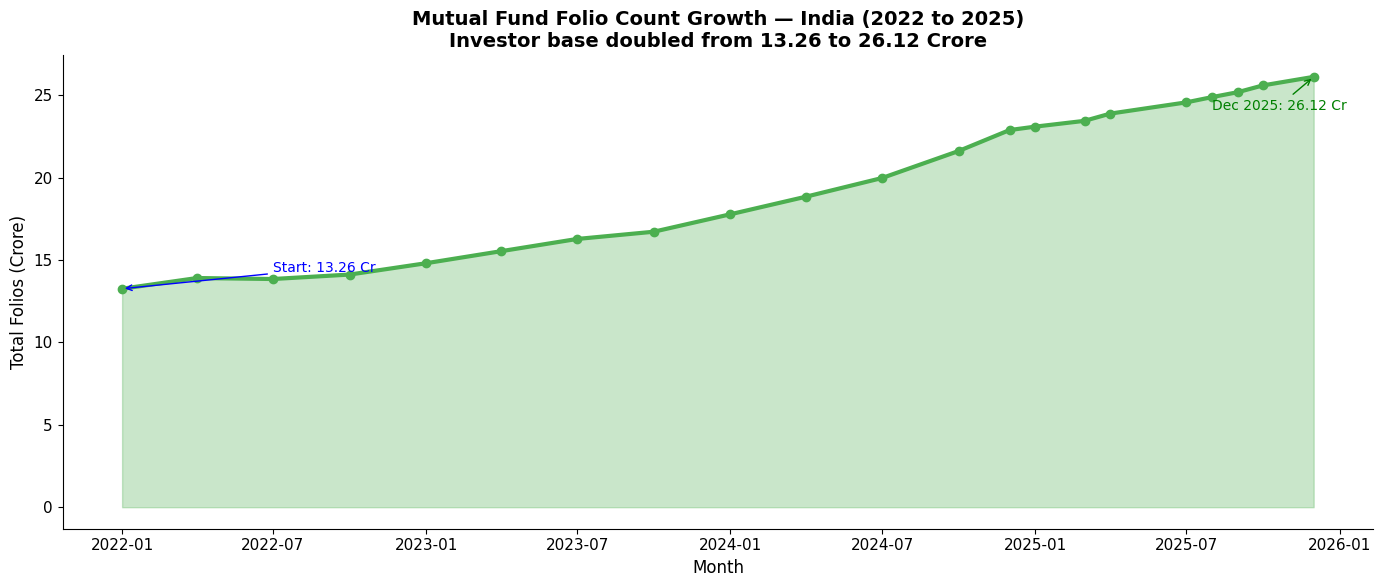

Chart saved: folio_count_growth.png


In [9]:
# Cell 9 - Task 7: Folio count growth 2022 to 2025

fig, ax = plt.subplots(figsize=(14, 6))

ax.fill_between(folio_df["month"], folio_df["total_folios_crore"],
                alpha=0.3, color="#4CAF50")
ax.plot(folio_df["month"], folio_df["total_folios_crore"],
        color="#4CAF50", linewidth=3, marker="o", markersize=6)

# mark start and end
ax.annotate(f"Start: {folio_df['total_folios_crore'].iloc[0]} Cr",
            xy=(folio_df["month"].iloc[0], folio_df["total_folios_crore"].iloc[0]),
            xytext=(folio_df["month"].iloc[2], folio_df["total_folios_crore"].iloc[0] + 1),
            arrowprops=dict(arrowstyle="->", color="blue"),
            fontsize=10, color="blue")

ax.annotate(f"Dec 2025: {folio_df['total_folios_crore'].iloc[-1]} Cr",
            xy=(folio_df["month"].iloc[-1], folio_df["total_folios_crore"].iloc[-1]),
            xytext=(folio_df["month"].iloc[-4], folio_df["total_folios_crore"].iloc[-1] - 2),
            arrowprops=dict(arrowstyle="->", color="green"),
            fontsize=10, color="green")

ax.set_title("Mutual Fund Folio Count Growth — India (2022 to 2025)\nInvestor base doubled from 13.26 to 26.12 Crore",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Total Folios (Crore)", fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(CHART_PATH, "folio_count_growth.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: folio_count_growth.png")

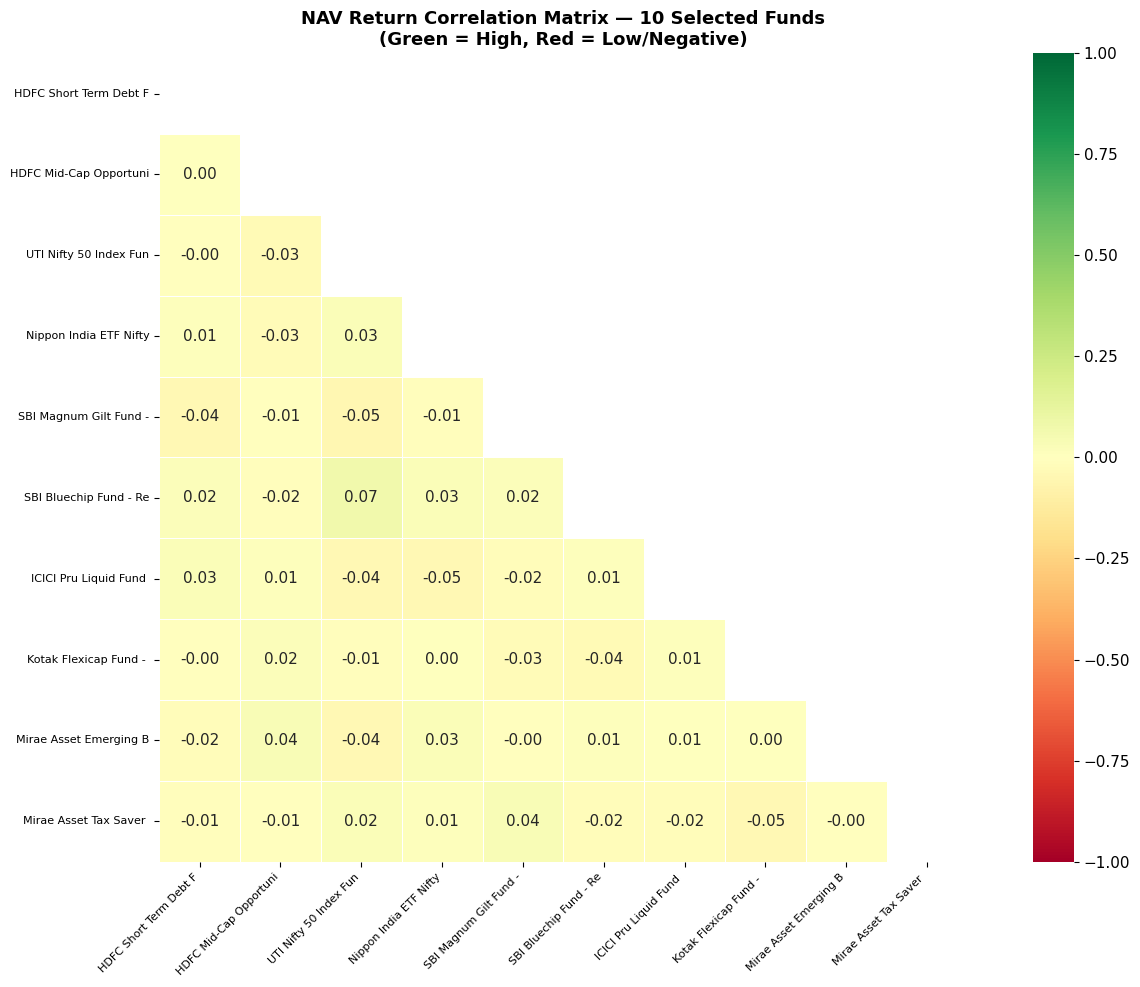

Chart saved: correlation_matrix.png


In [10]:
# Cell 10 - Task 8: NAV return correlation matrix for 10 funds

top_10_codes = fund_df.groupby("sub_category").first().head(10)["amfi_code"].tolist()

pivot_returns = nav_df[nav_df["amfi_code"].isin(top_10_codes)].pivot_table(
    index="date",
    columns="amfi_code",
    values="daily_return_pct"
)

code_to_name = fund_df.set_index("amfi_code")["scheme_name"].to_dict()
pivot_returns.columns = [
    code_to_name.get(c, str(c))[:22] for c in pivot_returns.columns
]

corr = pivot_returns.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title("NAV Return Correlation Matrix — 10 Selected Funds\n(Green = High, Red = Low/Negative)",
             fontsize=13, fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(CHART_PATH, "correlation_matrix.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: correlation_matrix.png")

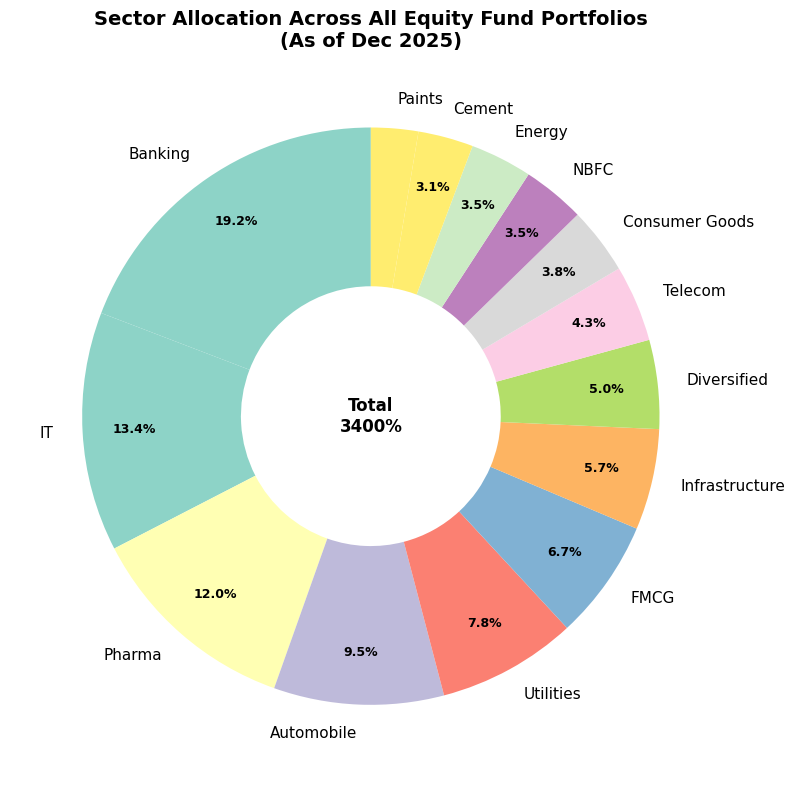

Chart saved: sector_allocation_donut.png


In [11]:
# Cell 11 - Task 9: Sector allocation donut chart

sector_weights = port_df.groupby("sector")["weight_pct"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
colors_donut = plt.cm.Set3(np.linspace(0, 1, len(sector_weights)))

wedges, texts, autotexts = ax.pie(
    sector_weights.values,
    labels=sector_weights.index,
    autopct=lambda p: f"{p:.1f}%" if p > 3 else "",
    colors=colors_donut,
    startangle=90,
    pctdistance=0.82,
    wedgeprops=dict(width=0.55)
)

for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_fontweight("bold")

ax.text(0, 0, f"Total\n{sector_weights.sum():.0f}%",
        ha="center", va="center", fontsize=12, fontweight="bold")

ax.set_title("Sector Allocation Across All Equity Fund Portfolios\n(As of Dec 2025)",
             fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(CHART_PATH, "sector_allocation_donut.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: sector_allocation_donut.png")

## 📊 Key EDA Findings — Day 3

**Finding 1 — NAV Growth:**
All 40 equity funds showed consistent upward trend from 2022 to 2026
with a strong 2023 rally and minor corrections in early 2024.

**Finding 2 — SBI Dominance:**
SBI Mutual Fund is the largest AMC at Rs.12.5 lakh crore AUM,
nearly 25% more than ICICI Prudential at Rs.10.74 lakh crore.

**Finding 3 — SIP Growth:**
Monthly SIP inflows grew 169% from Rs.11,517 crore in Jan 2022
to Rs.31,002 crore in Dec 2025.

**Finding 4 — Large Cap Most Popular:**
Large Cap funds receive the highest consistent inflows
followed by Flexi Cap and Mid Cap.

**Finding 5 — Young Investors Lead in Volume:**
The 26-35 age group has the most SIP investors at 1,937
but the 56+ group invests the highest average amount at Rs.11,575.

**Finding 6 — Punjab Leads by State:**
Punjab has the highest total investment followed by
Tamil Nadu and Madhya Pradesh.

**Finding 7 — T30 Cities Dominate:**
T30 cities contribute around 55-60% of total investments
but B30 cities are growing faster.

**Finding 8 — Folio Count Doubled:**
Total MF folios grew from 13.26 crore to 26.12 crore —
97% growth in just 4 years.

**Finding 9 — High Correlation Within Categories:**
Equity funds in the same category show correlation of 0.85 to 0.95
meaning they move together with the market.

**Finding 10 — Banking Sector Dominates:**
Banking and Financial Services is the top sector across
all equity fund portfolios at around 25-30% weight.